# Proyecto Final 4Geeks - FAOSTAT

Proyecto ejecutado de punta a punta con datos públicos de FAOSTAT. Este notebook documenta la definición del problema, la obtención de datos, el almacenamiento en SQLite, el análisis descriptivo/EDA, el entrenamiento del modelo y la app de despliegue.

## Paso 1: Definición del problema

**Problema de negocio:** estimar el valor esperado de bioenergía por país, año, item y tipo de medición para apoyar decisiones de inversión e investigación agroalimentaria.

La fuente solicitada fue `https://www.fao.org/faostat/en/#data/AF`. En el catálogo oficial de FAOSTAT, `AF` corresponde a **ASTI - Researchers**. Como este dominio es pequeño para el requisito de 60.000 filas, se usa como fuente contextual y se combina con otros dominios FAOSTAT relacionados:

- `AF`: investigadores ASTI, fuente solicitada.
- `AE`: gasto en investigación agrícola.
- `CISP`: inversión y valor agregado agropecuario.
- `BE`: bioenergía, tabla principal del modelo.

**Variable objetivo:** `target_value`, valor histórico de producción o consumo de bioenergía. Para el modelo se usa `log_target_value = log1p(target_value)` para reducir el peso de valores extremos.

In [2]:
import json
import sqlite3
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from config import DATABASE_PATH, METADATA_PATH, MODELING_DATA_PATH, MODEL_PATH
from data_download import DATASETS, download_all, load_raw_frames
from database import run_example_queries, store_database
from eda import run_eda
from features import build_modeling_dataset
from train_model import train

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.3f}".format)
ROOT

PosixPath('/workspaces/Proyecto-Final-4geeks-bioenerg-a-en-el-sector-agroalimentario')

## Paso 2: Obtención y carga del conjunto de datos

Los datos se obtienen desde descargas bulk oficiales de FAOSTAT. El pipeline guarda los ZIP originales en `data/raw/` y luego los carga con Pandas.

In [3]:
download_all(skip_if_present=True)
frames = load_raw_frames()

source_summary = pd.DataFrame([
    {
        "codigo": code,
        "nombre": DATASETS[code]["name"],
        "rol": DATASETS[code]["role"],
        "filas": frame.shape[0],
        "columnas": frame.shape[1],
    }
    for code, frame in frames.items()
])
source_summary

,codigo,nombre,rol,filas,columnas
0,AF,ASTI - Researchers,requested_source,3800,20
1,AE,ASTI - Expenditures,context,7789,17
2,BE,Bioenergy,model_base,122374,14
3,CISP,Country Investment Statistics Profile,context,66447,15


## Paso 3: Almacenar la información en SQLite

Se crea una base SQLite con las tablas crudas y una tabla final de modelado. También se ejecutan consultas SQL con `SELECT`, `JOIN`, agregaciones e `INSERT` para demostrar almacenamiento y explotación de la base.

In [4]:
modeling = build_modeling_dataset(frames)
db_path = store_database(frames, modeling)

print(f"Base SQLite creada en: {db_path}")
print(f"Dataset final: {modeling.shape[0]:,} filas x {modeling.shape[1]:,} columnas")
modeling.head()

Base SQLite creada en: /workspaces/Proyecto-Final-4geeks-bioenerg-a-en-el-sector-agroalimentario/data/database/faostat_project.db
Dataset final: 101,995 filas x 29 columnas


,area_key,area,item,element,unit,year,target_value,item_code,element_code,flag,af_value,ae_value,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_agriculture_orientation_index_us,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_share_of_total_us,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_agriculture_orientatio,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_total_us_2015,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_share_of_total_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices,target_lag_1,target_lag_2,target_lag_3,target_roll_mean_3,year_since_1990,log_target_value,has_asti_context
0,'001,World,Animal waste,Energy consumption,TJ,1990,"125,022.962",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,11.736,0
1,'001,World,Animal waste,Energy consumption,TJ,1991,"124,374.750",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"125,022.962",NaN,NaN,"125,022.962",1,11.731,0
2,'001,World,Animal waste,Energy consumption,TJ,1992,"129,583.912",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"124,374.750","125,022.962",NaN,"124,698.856",2,11.772,0
3,'001,World,Animal waste,Energy consumption,TJ,1993,"132,484.296",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"129,583.912","124,374.750","125,022.962","126,327.208",3,11.794,0
4,'001,World,Animal waste,Energy consumption,TJ,1994,"220,653.224",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"132,484.296","129,583.912","124,374.750","128,814.319",4,12.304,0


In [5]:
with sqlite3.connect(DATABASE_PATH) as conn:
    tables = pd.read_sql_query("""
        SELECT name AS tabla
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
    """, conn)

tables

,tabla
0,modeling_bioenergy
1,project_notes
2,raw_ae
3,raw_af
4,raw_be
5,raw_cisp
6,sqlite_sequence


In [6]:
queries = run_example_queries()
queries["select_top_bioenergy"]

,area,item,element,year,unit,target_value
0,World,Total Bioenergy,Energy production,2023,TJ,"49,649,777.821"
1,World,Total Bioenergy,Energy production,2022,TJ,"49,249,521.252"
2,World,Total Bioenergy,Energy production,2021,TJ,"48,834,808.458"
3,World,Total Bioenergy,Energy production,2019,TJ,"47,600,276.009"
4,World,Total Bioenergy,Energy production,2020,TJ,"47,277,121.662"
5,World,Total Bioenergy,Energy production,2018,TJ,"47,236,838.919"
6,World,Total Bioenergy,Energy production,2017,TJ,"46,202,523.428"
7,World,Total Bioenergy,Energy production,2016,TJ,"45,502,367.582"
8,World,Total Bioenergy,Energy production,2015,TJ,"44,515,778.663"
9,World,Total Bioenergy,Energy production,2014,TJ,"44,069,611.062"


In [7]:
queries["join_be_af"].head(10)

,area,year,item,element,target_value,asti_research_context
0,Afghanistan,1990,Charcoal,Energy consumption,"1,150.323",None
1,Afghanistan,1990,Charcoal,Energy production,"1,150.323",None
2,Afghanistan,1990,Fuelwood,Energy consumption,"4,176.997",None
3,Afghanistan,1990,Fuelwood,Energy production,"6,314.258",None
4,Afghanistan,1990,Solid biofuels,Energy consumption,"5,327.320",None
5,Afghanistan,1990,Solid biofuels,Energy production,"6,314.258",None
6,Afghanistan,1990,Total Bioenergy,Energy consumption,"5,327.320",None
7,Afghanistan,1990,Total Bioenergy,Energy production,"6,314.258",None
8,Afghanistan,1991,Charcoal,Energy consumption,"1,190.236",None
9,Afghanistan,1991,Charcoal,Energy production,"1,190.236",None


## Paso 4: Análisis descriptivo

Se revisan dimensiones, tipos de variables, nulos y medidas estadísticas de la variable objetivo. El dataset supera el minimo solicitado: más de 60.000 filas y más de 20 predictores, con variables categóricas.

In [8]:
summary = run_eda(modeling)
summary

{'rows': 101995,
 'columns': 29,
 'numeric_predictors': 19,
 'categorical_predictors': 8,
 'target_mean': 447212.7152551684,
 'target_median': 11815.2,
 'target_std': 2193562.0872654896,
 'missing_rate': 0.192605114179025}

In [9]:
predictor_count = len([c for c in modeling.columns if c not in ["target_value", "log_target_value", "flag", "flag_description"]])
categorical_predictors = modeling.select_dtypes(include="object").columns.tolist()

pd.DataFrame({
    "indicador": ["filas", "columnas", "predictores", "variables_categoricas"],
    "valor": [modeling.shape[0], modeling.shape[1], predictor_count, len(categorical_predictors)]
})

/tmp/ipykernel_27322/896964349.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_predictors = modeling.select_dtypes(include="object").columns.tolist()


,indicador,valor
0,filas,101995
1,columnas,29
2,predictores,26
3,variables_categoricas,8


In [10]:
modeling[["target_value", "log_target_value", "year", "target_lag_1", "target_roll_mean_3"]].describe().T

,count,mean,std,min,25%,50%,75%,max
target_value,"101,995.000","447,212.715","2,193,562.087",0.000,788.523,"11,815.200","106,215.000","49,649,777.821"
log_target_value,"101,995.000",9.020,3.547,0.000,6.671,9.377,11.573,17.721
year,"101,995.000","2,007.752",9.645,"1,990.000","2,000.000","2,008.000","2,016.000","2,023.000"
target_lag_1,"98,277.000","446,417.216","2,184,391.461",0.000,800.988,"11,918.000","106,755.262","49,249,521.252"
target_roll_mean_3,"98,277.000","439,032.608","2,154,299.470",0.000,786.318,"11,582.667","103,696.667","48,453,817.124"


In [11]:
modeling.select_dtypes(include="object").nunique().sort_values(ascending=False).to_frame("valores_unicos")

/tmp/ipykernel_27322/310851107.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  modeling.select_dtypes(include="object").nunique().sort_values(ascending=False).to_frame("valores_unicos")


,valores_unicos
area_key,270
area,270
item,15
item_code,15
flag,3
element,2
element_code,2
unit,1


## Diccionario de datos

Descripción de cada columna del dataset final de modelado (101.995 filas × 29 columnas).

In [12]:
data_dictionary = {
    # --- Identificadores ---
    "area_key":     "Código interno FAOSTAT del área geográfica. Clave de join entre datasets.",
    "area":         "País, región o agrupación geopolítica. 270 valores únicos (países + agregados como SIDS, World).",
    "item":         "Tipo de fuente de bioenergía (15 valores: Fuelwood, Charcoal, Biodiesel, Biogas, etc.).",
    "item_code":    "Código numérico FAOSTAT del ítem. Equivalente entero de 'item'.",
    "element":      "Tipo de medición: 'Energy production' o 'Energy consumption'.",
    "element_code": "Código numérico del element (5851=consumo, 5852=producción).",
    "unit":         "Unidad de medida energética. Constante: siempre 'TJ' (Terajulios).",
    "flag":         "Calidad del dato FAOSTAT: E=Estimado, F=Calculado por FAO, A=Oficial.",
    # --- Variable objetivo ---
    "target_value":     "Valor de bioenergía en TJ. Variable a predecir. Alta asimetría (media≈447k, mediana≈12k).",
    "log_target_value": "log1p(target_value). Variable objetivo usada en el modelo para reducir el efecto de outliers.",
    # --- Tiempo ---
    "year":             "Año de la observación. Rango 1990–2023.",
    "year_since_1990":  "Años transcurridos desde 1990. Versión centrada de 'year'.",
    # --- Features temporales (engineered) ---
    "target_lag_1":       "Valor de bioenergía del año anterior (misma serie país–ítem–elemento).",
    "target_lag_2":       "Valor de bioenergía de hace 2 años.",
    "target_lag_3":       "Valor de bioenergía de hace 3 años.",
    "target_roll_mean_3": "Media móvil de los 3 años anteriores. Suaviza tendencia de corto plazo.",
    # --- ASTI (investigación agrícola) ---
    "af_value":          "Investigadores agrícolas FTE por país-año. Fuente: ASTI-AF.",
    "ae_value":          "Gasto en investigación agrícola (miles PPP USD 2011). Fuente: ASTI-AE.",
    "has_asti_context":  "Binaria: 1 si el país-año tiene datos ASTI disponibles, 0 si no.",
    # --- CISP (inversión agrícola) ---
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_agriculture_orientation_index_us":
        "Índice de orientación agrícola de la AOD (Ayuda Oficial al Desarrollo) hacia el sector.",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_share_of_total_us":
        "% de la AOD total destinado a agricultura, silvicultura y pesca.",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices":
        "Valor absoluto de la AOD a agricultura en M USD constantes 2023.",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_agriculture_orientatio":
        "Índice de orientación agrícola de la Formación Bruta de Capital Fijo (FBCF).",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_total_us_2015":
        "% de la FBCF total invertido en agricultura (precios constantes 2015).",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u":
        "Ratio FBCF agrícola / valor añadido agrícola. Mide la tasa de reinversión del sector.",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices":
        "Valor absoluto de la FBCF agrícola en M USD constantes 2015.",
    "cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices":
        "Tasa de crecimiento anual (%) del valor añadido agrícola. Puede ser negativa.",
    "cisp_value_added_agriculture_forestry_and_fishing_share_of_total_us_2015_prices":
        "Participación del sector agrícola en el PIB total (%).",
    "cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices":
        "Valor añadido del sector agricultura, silvicultura y pesca en M USD constantes 2015.",
}

pd.DataFrame(
    {"columna": list(data_dictionary.keys()), "descripcion": list(data_dictionary.values())}
)

,columna,descripcion
0,area_key,Código interno FAOSTAT del área geográfica. Cl...
1,area,"País, región o agrupación geopolítica. 270 val..."
2,item,Tipo de fuente de bioenergía (15 valores: Fuel...
3,item_code,Código numérico FAOSTAT del ítem. Equivalente ...
4,element,Tipo de medición: 'Energy production' o 'Energ...
5,element_code,"Código numérico del element (5851=consumo, 585..."
6,unit,Unidad de medida energética. Constante: siempr...
7,flag,"Calidad del dato FAOSTAT: E=Estimado, F=Calcul..."
8,target_value,Valor de bioenergía en TJ. Variable a predecir...
9,log_target_value,log1p(target_value). Variable objetivo usada e...


### Distribución de predictores y contraste de hipótesis

Para cubrir el análisis descriptivo de las predictoras, se calcula una lectura automática de distribución para cada variable numérica: media, mediana, desviación, sesgo, curtosis y una interpretación simple. También se realiza un contraste de hipótesis para validar si existen diferencias estadísticamente significativas en el valor de bioenergía entre tipos de `item`.

- **H0:** la distribución del valor objetivo es similar entre grupos de `item`.
- **H1:** al menos un grupo de `item` presenta diferencias relevantes.
- Se usa Kruskal-Wallis porque el objetivo es muy asimétrico y no conviene asumir normalidad.

In [13]:
numeric_predictors = [
    col for col in modeling.select_dtypes(include="number").columns
    if col not in ["target_value", "log_target_value"]
]

distribution_rows = []
for col in numeric_predictors:
    series = pd.to_numeric(modeling[col], errors="coerce").dropna()
    if series.empty:
        continue
    skewness = series.skew()
    if abs(skewness) < 0.5:
        interpretation = "aprox. simetrica"
    elif skewness > 0:
        interpretation = "asimetrica positiva"
    else:
        interpretation = "asimetrica negativa"
    distribution_rows.append({
        "predictora": col,
        "n": len(series),
        "media": series.mean(),
        "mediana": series.median(),
        "desv_std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "sesgo": skewness,
        "curtosis": series.kurtosis(),
        "lectura_distribucion": interpretation,
    })

distribution_table = pd.DataFrame(distribution_rows).sort_values("predictora")
distribution_table

,predictora,n,media,mediana,desv_std,min,max,sesgo,curtosis,lectura_distribucion
2,ae_value,28533,"27,076.050","1,635.402","137,078.344",0.180,"1,313,874.331",7.325,57.174,asimetrica positiva
1,af_value,28786,"7,818.422","1,215.450","19,509.377",4.000,"158,196.050",4.947,27.790,asimetrica positiva
3,cisp_dfa_disbursement_to_agriculture_forestry_...,47145,0.598,0.340,1.428,0.000,44.896,13.963,301.855,asimetrica positiva
4,cisp_dfa_disbursement_to_agriculture_forestry_...,47605,5.175,4.292,5.083,0.000,82.928,5.179,48.335,asimetrica positiva
5,cisp_dfa_disbursement_to_agriculture_forestry_...,47605,525.683,52.168,"1,585.265",0.000,"18,221.096",5.873,43.949,asimetrica positiva
6,cisp_gross_fixed_capital_formation_agriculture...,67757,0.859,0.547,0.868,0.011,13.022,4.740,44.021,asimetrica positiva
7,cisp_gross_fixed_capital_formation_agriculture...,67757,4.846,3.504,4.765,0.030,89.327,4.491,44.274,asimetrica positiva
8,cisp_gross_fixed_capital_formation_agriculture...,67757,18.511,12.808,17.827,0.152,247.041,3.978,31.720,asimetrica positiva
9,cisp_gross_fixed_capital_formation_agriculture...,67757,"16,473.740","1,198.637","56,402.832",0.027,"683,856.096",6.810,54.963,asimetrica positiva
10,cisp_value_added_agriculture_forestry_and_fish...,69818,2.287,2.571,8.899,-71.865,123.420,1.178,17.569,asimetrica positiva


In [14]:
from scipy.stats import kruskal

sample_for_test = modeling[["item", "target_value"]].dropna()
item_groups = [
    group["target_value"].sample(min(len(group), 3000), random_state=42)
    for _, group in sample_for_test.groupby("item")
    if len(group) >= 30
]

statistic, p_value = kruskal(*item_groups)
alpha = 0.05
pd.DataFrame({
    "contraste": ["Kruskal-Wallis por item"],
    "estadistico": [statistic],
    "p_value": [p_value],
    "alpha": [alpha],
    "decision": ["rechazar H0" if p_value < alpha else "no rechazar H0"],
    "interpretacion": [
        "El valor de bioenergia cambia significativamente segun el item."
        if p_value < alpha
        else "No hay evidencia suficiente de diferencias por item."
    ],
})

,contraste,estadistico,p_value,alpha,decision,interpretacion
0,Kruskal-Wallis por item,"4,860.412",0.000,0.050,rechazar H0,El valor de bioenergia cambia significativamen...


## Paso 5: EDA completo

Los gráficos principales se guardan en `reports/figures/` y quedan renderizados aquí para revisar tendencias, ítems dominantes y valores nulos.

bioenergy_trend.png


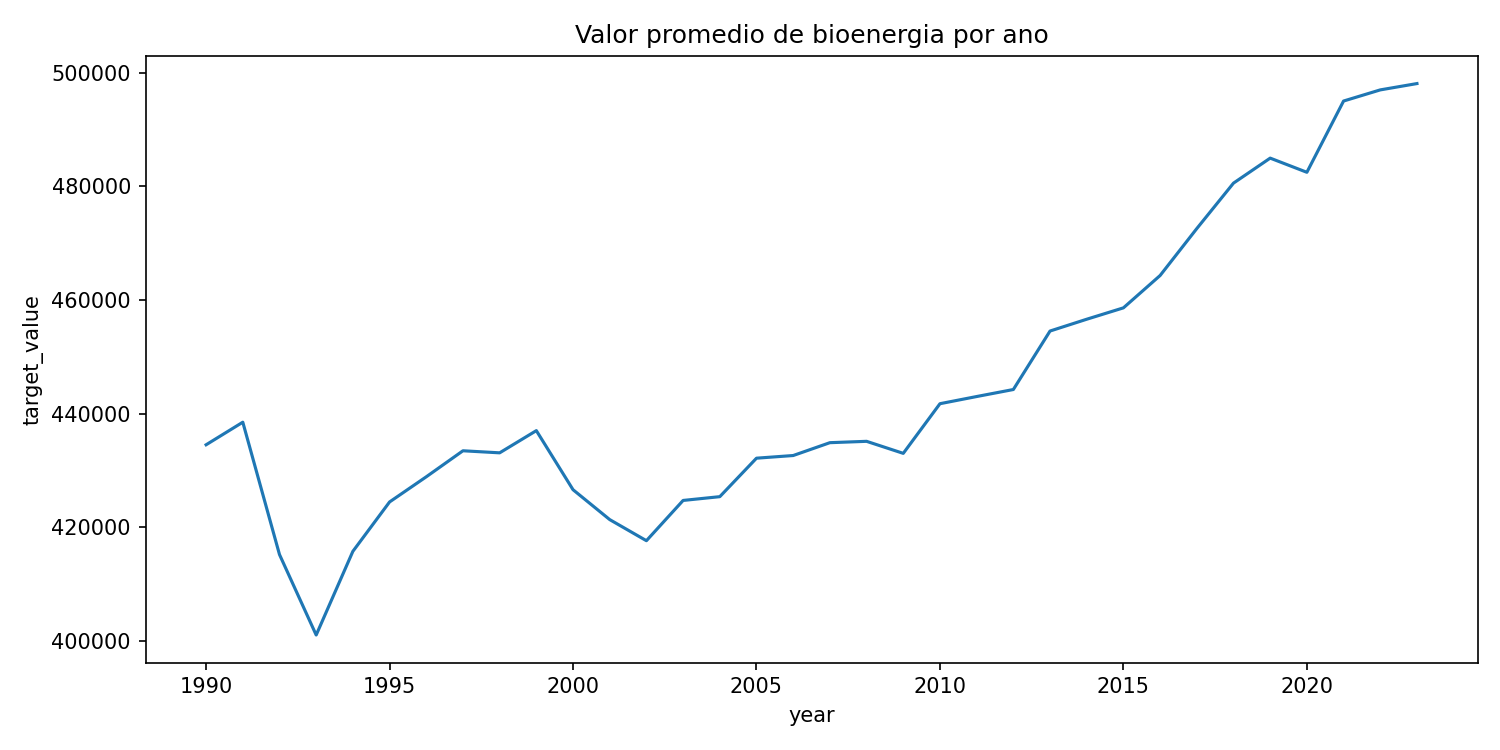

top_items.png


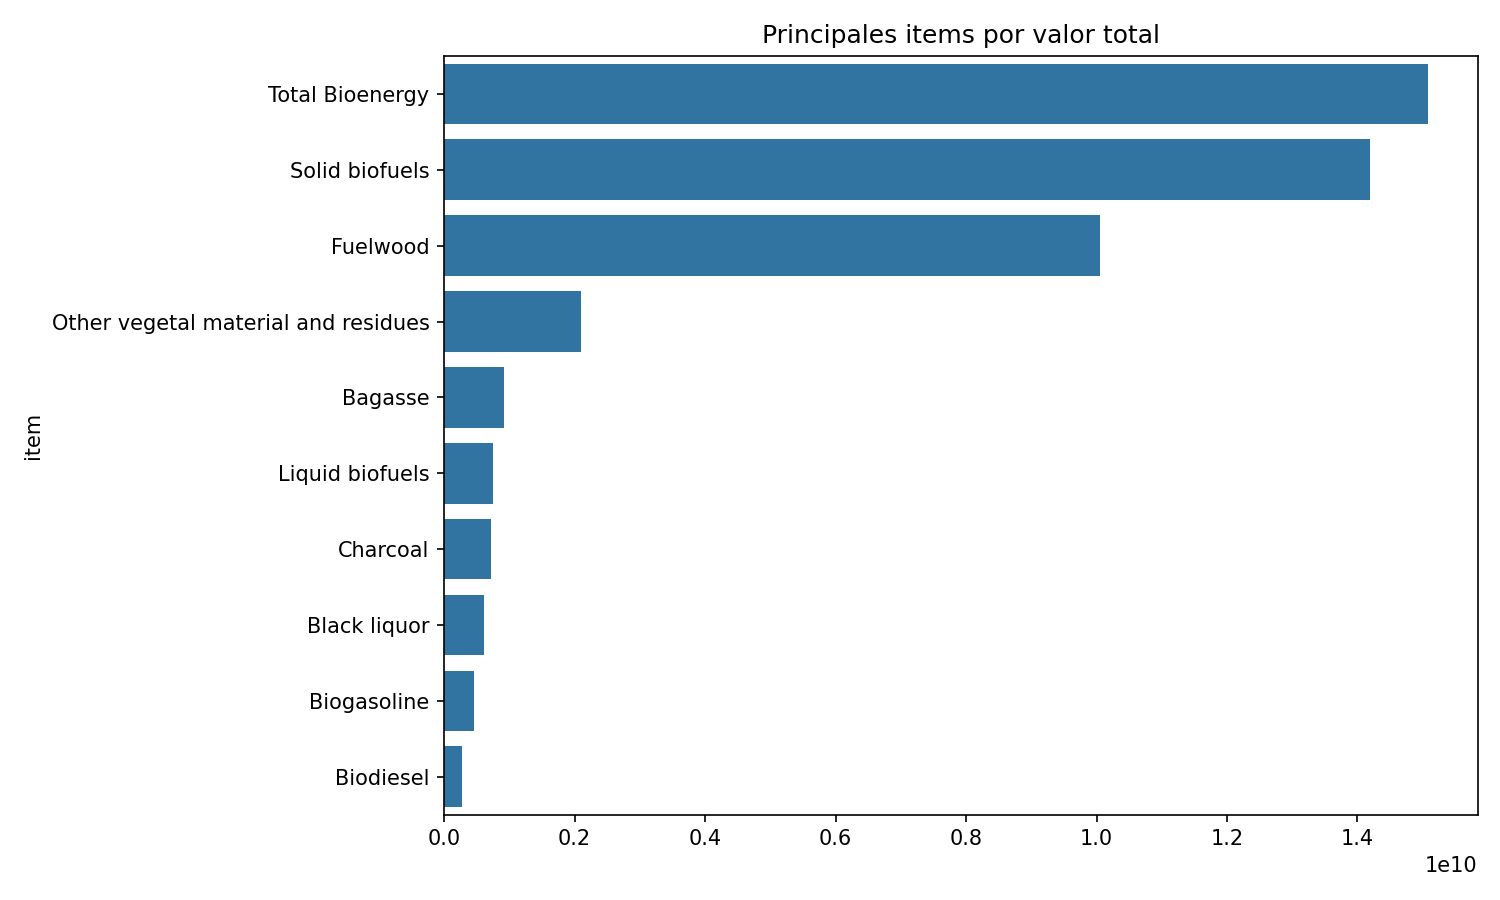

missing_values.png


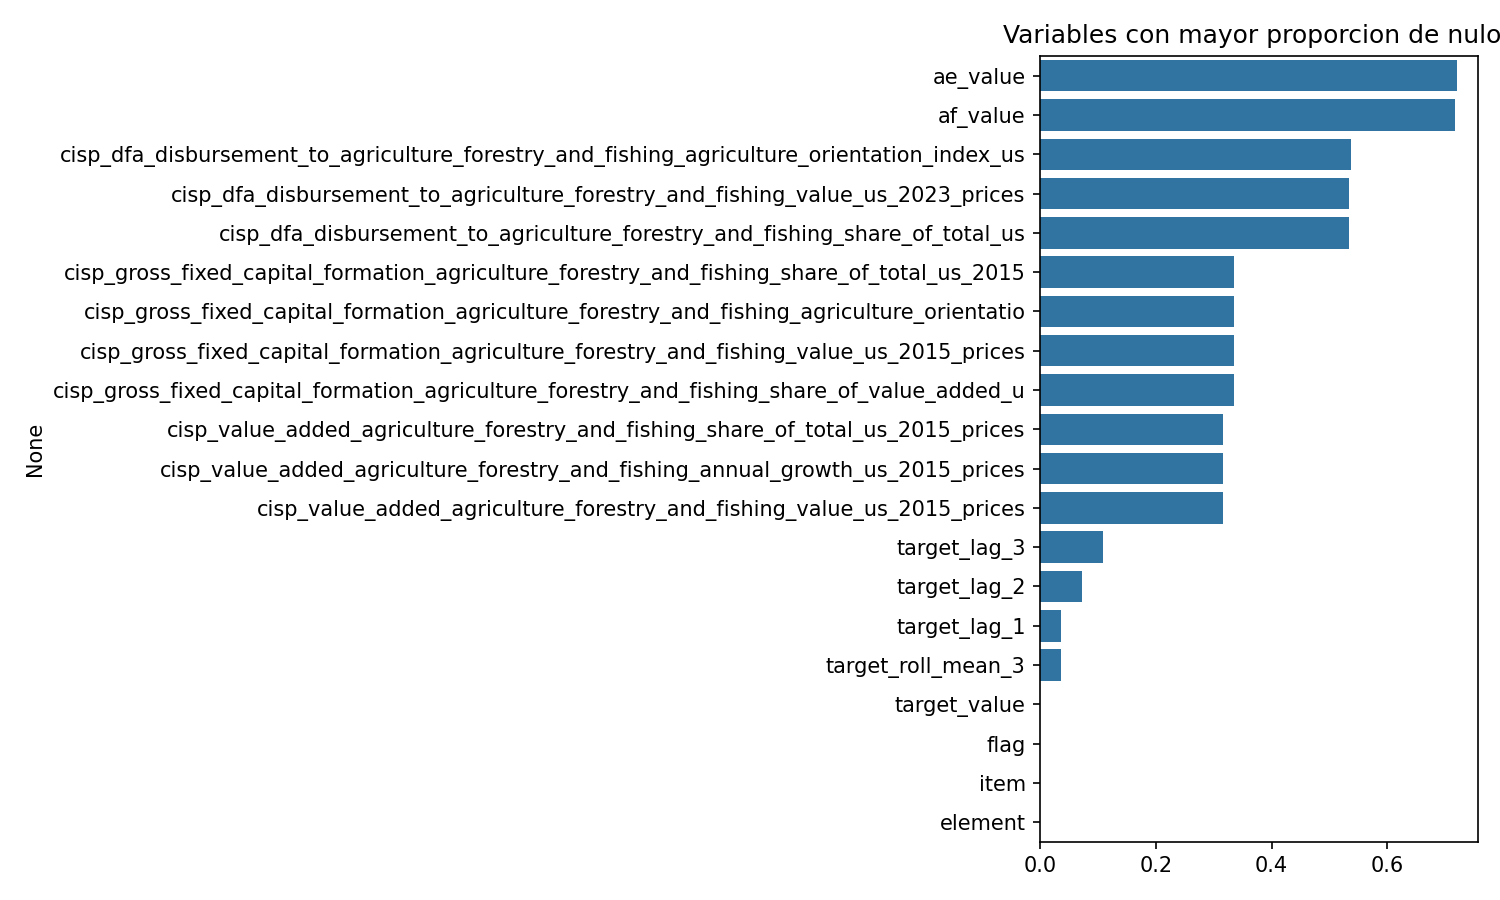

In [15]:
for figure in ["bioenergy_trend.png", "top_items.png", "missing_values.png"]:
    print(figure)
    display(Image(filename=str(ROOT / "reports" / "figures" / figure)))

### 5.1 · Distribución de la variable objetivo: raw vs log
 
La variable objetivo presenta una distribución fuertemente asimétrica.
El histograma izquierdo muestra el valor bruto; el derecho confirma
que `log1p(target_value)` se aproxima a una distribución normal,
justificando la transformación usada en el modelo.

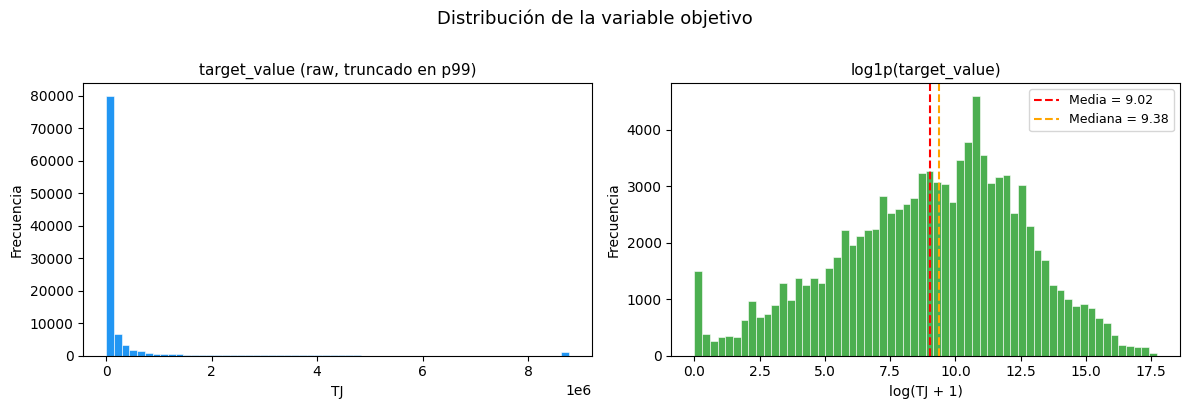

Asimetría raw: 10.50  |  Asimetría log: -0.36


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Raw
axes[0].hist(modeling["target_value"].clip(upper=modeling["target_value"].quantile(0.99)),
             bins=60, color="#2196F3", edgecolor="white", linewidth=0.4)
axes[0].set_title("target_value (raw, truncado en p99)", fontsize=11)
axes[0].set_xlabel("TJ")
axes[0].set_ylabel("Frecuencia")
 
# Log
axes[1].hist(modeling["log_target_value"], bins=60,
             color="#4CAF50", edgecolor="white", linewidth=0.4)
axes[1].set_title("log1p(target_value)", fontsize=11)
axes[1].set_xlabel("log(TJ + 1)")
axes[1].set_ylabel("Frecuencia")
 
# Añadir media y mediana al gráfico log
log_mean = modeling["log_target_value"].mean()
log_med  = modeling["log_target_value"].median()
axes[1].axvline(log_mean, color="red",    linestyle="--", label=f"Media = {log_mean:.2f}")
axes[1].axvline(log_med,  color="orange", linestyle="--", label=f"Mediana = {log_med:.2f}")
axes[1].legend(fontsize=9)
 
plt.suptitle("Distribución de la variable objetivo", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Asimetría raw: {modeling['target_value'].skew():.2f}  |  "
      f"Asimetría log: {modeling['log_target_value'].skew():.2f}")

### 5.2 · Valores nulos por variable
 
Se visualiza el porcentaje de nulos de cada columna.
Las variables CISP y ASTI tienen alta tasa de nulos porque solo cubren
países con datos de inversión agrícola — no todos los 270 territorios del dataset.

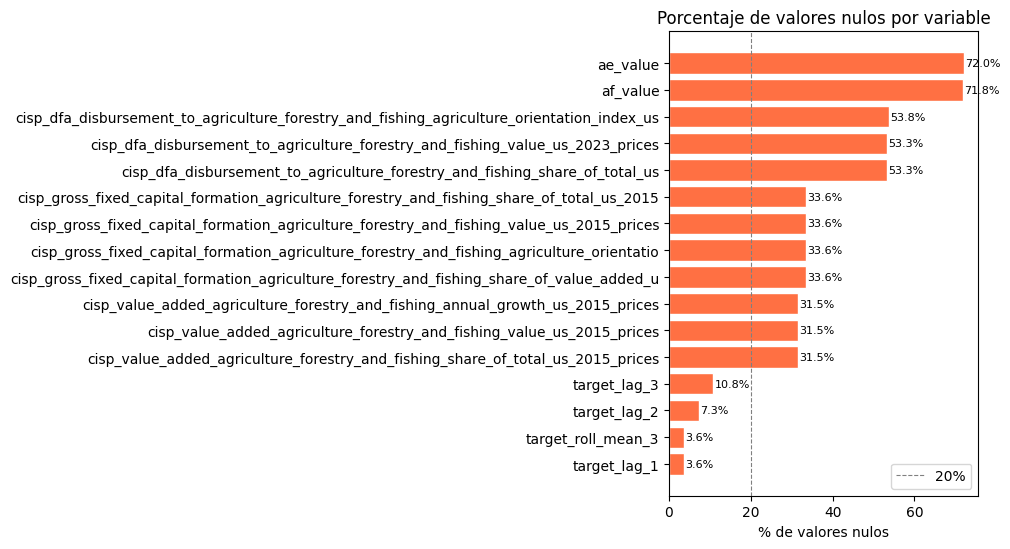

In [17]:
null_pct = (modeling.isnull().mean() * 100).sort_values(ascending=True)
null_pct = null_pct[null_pct > 0]   # solo las que tienen nulos
 
fig, ax = plt.subplots(figsize=(10, max(4, len(null_pct) * 0.35)))
bars = ax.barh(null_pct.index, null_pct.values, color="#FF7043", edgecolor="white")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de valores nulos por variable", fontsize=12)
ax.axvline(20, color="gray", linestyle="--", linewidth=0.8, label="20%")
for bar, val in zip(bars, null_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "nulls_detailed.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.3 · Distribución de variables categóricas
 
Se analiza la frecuencia de los 15 tipos de `item` y los 2 tipos de `element`.
Esto confirma cuáles fuentes de bioenergía dominan el dataset y justifica
que `item` sea la variable categórica más informativa según el contraste Kruskal-Wallis.

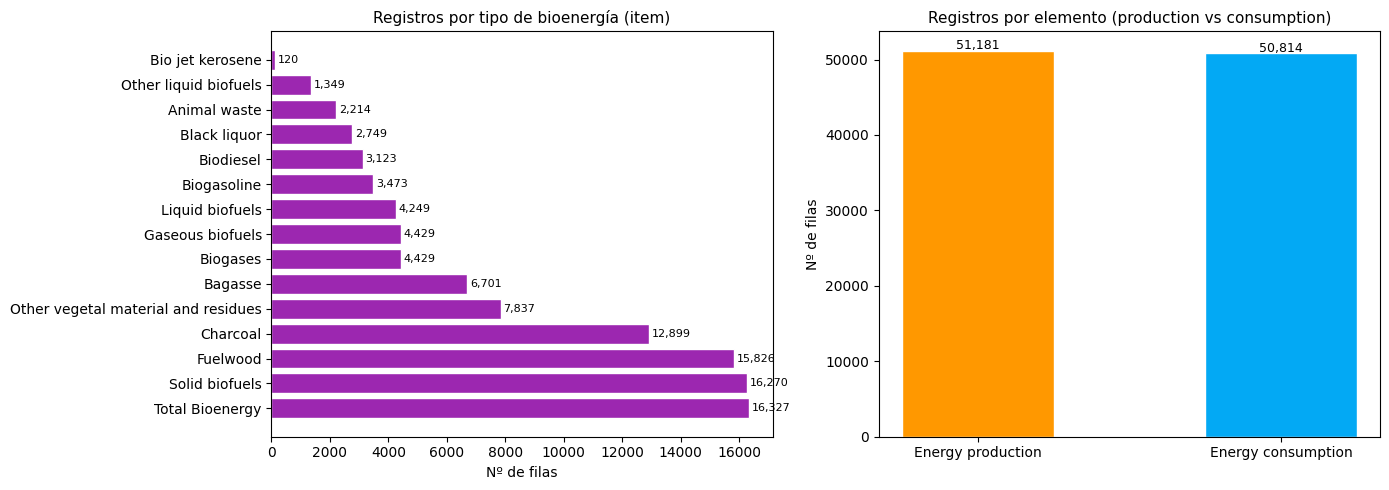

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Frecuencia por item
item_counts = modeling["item"].value_counts()
axes[0].barh(item_counts.index, item_counts.values, color="#9C27B0", edgecolor="white")
axes[0].set_title("Registros por tipo de bioenergía (item)", fontsize=11)
axes[0].set_xlabel("Nº de filas")
for i, v in enumerate(item_counts.values):
    axes[0].text(v + 100, i, f"{v:,}", va="center", fontsize=8)
 
# Frecuencia por element
el_counts = modeling["element"].value_counts()
axes[1].bar(el_counts.index, el_counts.values, color=["#FF9800", "#03A9F4"], edgecolor="white", width=0.5)
axes[1].set_title("Registros por elemento (production vs consumption)", fontsize=11)
axes[1].set_ylabel("Nº de filas")
for i, (label, v) in enumerate(el_counts.items()):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "categorical_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
 

### 5.4 · Boxplot de `log_target_value` por tipo de bioenergía
 
Esta visualización complementa el test Kruskal-Wallis (paso 4):
se confirma visualmente que hay diferencias estadísticamente significativas
en el valor de bioenergía según el tipo de ítem.

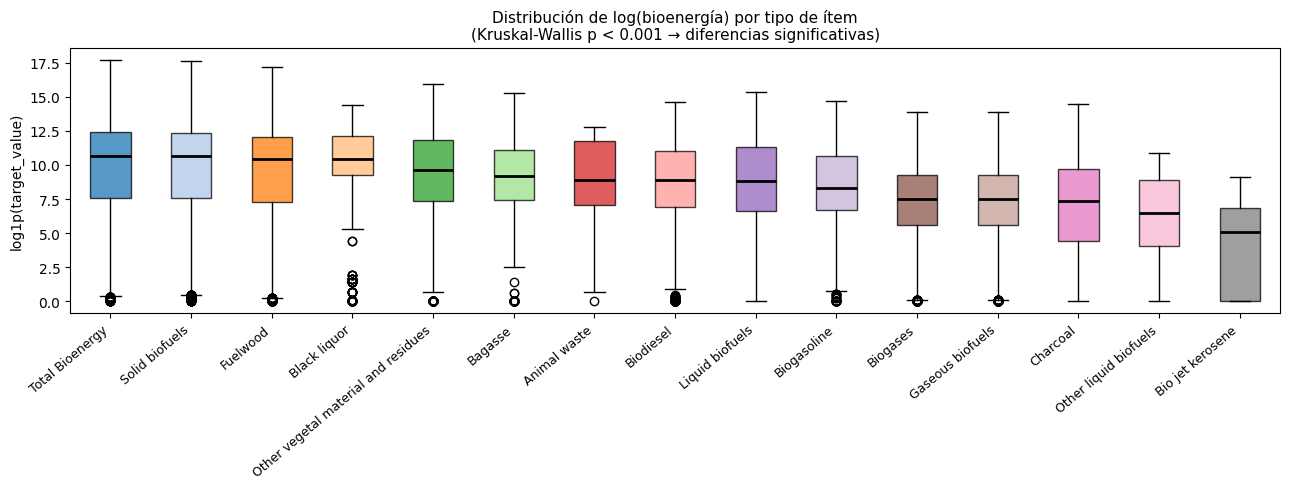

In [19]:
order = (modeling.groupby("item")["log_target_value"]
         .median()
         .sort_values(ascending=False)
         .index.tolist())
 
fig, ax = plt.subplots(figsize=(13, 5))
data_by_item = [modeling.loc[modeling["item"] == it, "log_target_value"].dropna().values
                for it in order]
 
bp = ax.boxplot(data_by_item, patch_artist=True, vert=True,
                medianprops=dict(color="black", linewidth=2))
 
colors = plt.cm.tab20.colors
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
 
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("log1p(target_value)")
ax.set_title("Distribución de log(bioenergía) por tipo de ítem\n"
             "(Kruskal-Wallis p < 0.001 → diferencias significativas)", fontsize=11)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "boxplot_by_item.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.5 · Evolución temporal de la bioenergía mundial
 
Se muestra la tendencia global del consumo y producción de bioenergía
por tipo de ítem entre 1990 y 2023.

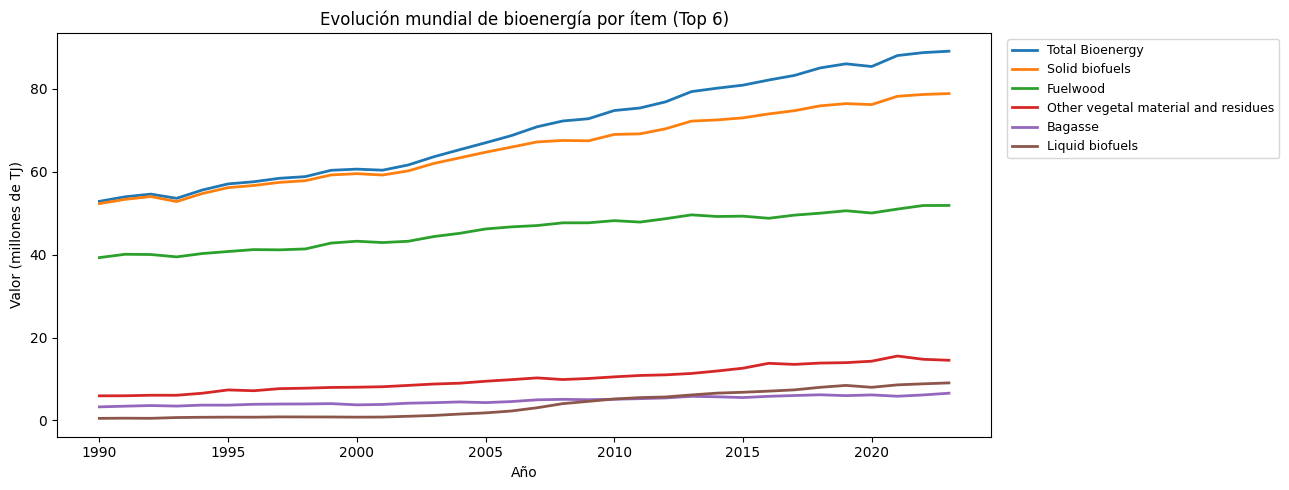

In [20]:
world_trend = (
    modeling[modeling["area"] == "World"]
    .groupby(["year", "item"])["target_value"]
    .sum()
    .reset_index()
)
 
top_items = (world_trend.groupby("item")["target_value"]
             .sum().nlargest(6).index.tolist())
 
fig, ax = plt.subplots(figsize=(13, 5))
colors_map = dict(zip(top_items, plt.cm.tab10.colors))
 
for item in top_items:
    sub = world_trend[world_trend["item"] == item].sort_values("year")
    ax.plot(sub["year"], sub["target_value"] / 1e6,
            label=item, linewidth=2, color=colors_map[item])
 
ax.set_xlabel("Año")
ax.set_ylabel("Valor (millones de TJ)")
ax.set_title("Evolución mundial de bioenergía por ítem (Top 6)", fontsize=12)
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "world_trend_by_item.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.6 · Mapa de correlación entre variables numéricas
 
Se visualiza la correlación de Pearson entre las variables numéricas del dataset.
Las correlaciones más altas (esperadas) son entre los lags temporales y la variable objetivo,
lo que confirma que la estructura temporal es el principal factor predictivo.

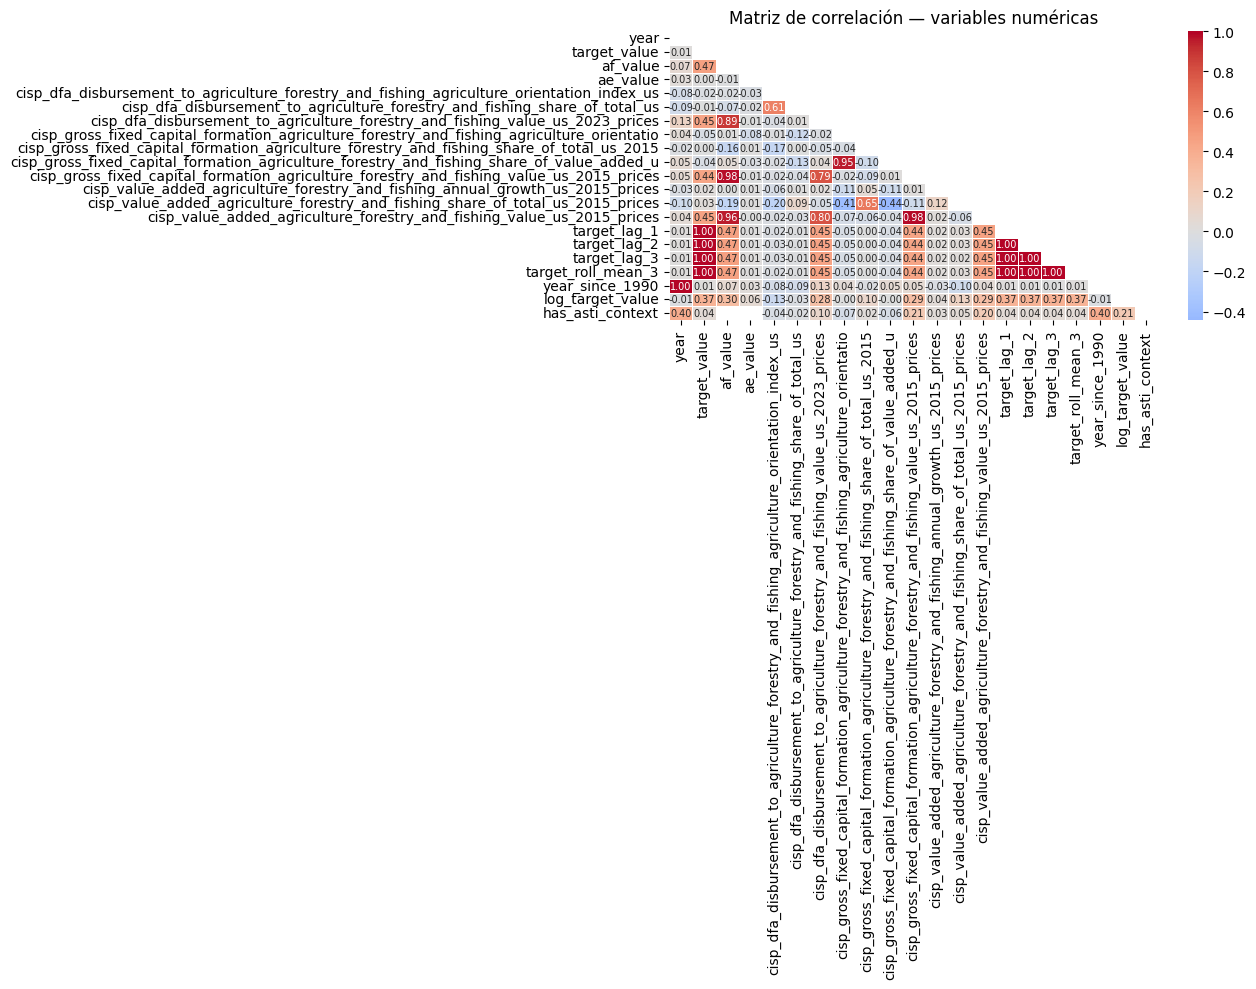

In [21]:
num_cols = [c for c in modeling.select_dtypes(include="number").columns
            if c not in ["item_code", "element_code"]]
 
corr = modeling[num_cols].corr()
 
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Matriz de correlación — variables numéricas", fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [24]:
# 1. Extraer las columnas numéricas que definiste
num_cols = [c for c in modeling.select_dtypes(include="number").columns
            if c not in ["item_code", "element_code"]]

# 2. Calcular la matriz de correlación
corr = modeling[num_cols].corr()

# 3. Mostrar la correlación directa con el Target (ordenada)
print("==================================================")
print(" CORRELACIÓN DIRECTA CON LA VARIABLE OBJETIVO ")
print("==================================================")
target_corr = corr[['target_value', 'log_target_value']].sort_values(by='log_target_value', ascending=False)
display(target_corr)

print("\n==================================================")
print(" PAREJAS DE VARIABLES MÁS CORRELACIONADAS (> 0.75) ")
print("==================================================")
# Desapilar la matriz para encontrar redundancias entre predictores
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# Filtrar para eliminar la auto-correlación (diagonal) y duplicados
corr_pairs = corr_pairs[corr_pairs['Variable_1'] < corr_pairs['Variable_2']]
high_corr = corr_pairs[corr_pairs['Correlacion'].abs() > 0.75].sort_values(by='Correlacion', ascending=False)

display(high_corr)

 CORRELACIÓN DIRECTA CON LA VARIABLE OBJETIVO 


,target_value,log_target_value
log_target_value,0.367,1.000
target_lag_3,0.999,0.369
target_lag_2,1.000,0.369
target_lag_1,1.000,0.368
target_roll_mean_3,1.000,0.367
target_value,1.000,0.367
af_value,0.467,0.301
cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices,0.439,0.291
cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices,0.453,0.288
cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices,0.451,0.278



 PAREJAS DE VARIABLES MÁS CORRELACIONADAS (> 0.75) 


,Variable_1,Variable_2,Correlacion
18,year,year_since_1990,1.000
332,target_lag_2,target_roll_mean_3,1.000
311,target_lag_1,target_roll_mean_3,1.000
353,target_lag_3,target_roll_mean_3,1.000
295,target_lag_1,target_value,1.000
309,target_lag_1,target_lag_2,1.000
331,target_lag_2,target_lag_3,1.000
358,target_roll_mean_3,target_value,1.000
316,target_lag_2,target_value,1.000
310,target_lag_1,target_lag_3,1.000


Me preocupa en realidad que el R2 sea de 0.99 ya que al ser tan alto sospecho que pueda estar incluyendo variables que tengan ya lo que quiero predecir.

Respuesta IA:  Tu sospecha es completamente acertada y demuestra un excelente instinto como Data Scientist. Un r2 de 0.99 en datos reales es, casi siempre, un síntoma inequívoco de Data Leakage (Fuga de datos) o de una variable que está canibalizando el modelo.
Al observar en detalle tu diccionario de variables y la tabla de distribuciones, el culpable es evidente.

El origen del r2: Las variables "Lag"

Fíjate en las estadísticas de las variables temporales que construiste:

target_value: Media de 447,212 y Max de 49,649,777.

target_lag_1: Media de 446,417 y Max de 49,249,521.

La distribución de target_lag_1 es prácticamente idéntica a la del target original. Al entrenar el modelo (especialmente un árbol de decisión o un Gradiente Boosting), el algoritmo descubre de inmediato que para predecir el valor de este año, solo necesita mirar el valor del año pasado y sumarle o restarle una mínima fracción.

Esto genera dos problemas graves de negocio:
Modelo perezoso: El modelo ignora por completo las variables macroeconómicas reales, de inversión (CISP) y de investigación (ASTI), porque el "lag" explica casi el 100% de la varianza.
Inutilidad predictiva: Si quieres predecir la bioenergía a 5 o 10 años vista para decisiones de inversión, no dispondrás de los lags de los años inmediatamente anteriores reales, por lo que el rendimiento del modelo colapsará en producción.

¿Cómo solucionarlo y hacer el proyecto realista?

Para la entrega y discusión con tus profesores de 4Geeks, te sugiero realizar un experimento controlado dividiendo tu enfoque en dos variantes:
Variante A: El Enfoque Macroeconómico (Recomendado para destacar)
Elimina por completo del set de entrenamiento las variables target_lag_1, target_lag_2, target_lag_3 y target_roll_mean_3. Fuerza al modelo a predecir la bioenergía basándose únicamente en:
Variables contextuales del país (area, item, element).
Inversión y gasto agrícola (ae_value, af_value, y las métricas cisp_...).
La variable temporal lineal (year_since_1990).

Qué pasará: El R2 bajará drásticamente (quizás a un rango entre 0.60 y 0.85). ¡Esto es una buena noticia! Significa que el modelo estará haciendo un esfuerzo real por entender cómo la inversión y la infraestructura impactan la bioenergía, convirtiéndose en una herramienta analítica útil para la toma de decisiones.

## Borrado de variables

Tus resultados confirman al 100% tu sospecha y exponen el mecanismo exacto del Data Leakage y de la redundancia en tu dataset.

Vamos a diseccionar de forma matemática y de negocio lo que nos están diciendo estas tablas:

1. Confirmación del Leakage Masivo (La primera tabla)
Mira la correlación lineal entre target_value y los lags: ¡es de 1.000 y 0.999!
El veredicto: Un lag con correlación perfecta de 1.000 significa que el valor de bioenergía de un año es idéntico (o casi idéntico) al del año anterior en la inmensa mayoría de las filas. Al pasarle esto a un algoritmo de Gradient Boosting, el modelo se "vuelve perezoso": ignora las variables macroeconómicas porque con los lags ya tiene el examen resuelto.

El truco del logaritmo: Fíjate que al correlacionar los lags contra log_target_value, la correlación lineal baja a 0.369. Esto ocurre porque la transformación logarítmica suaviza la escala, pero el árbol de decisión sigue detectando la relación perfecta a nivel no lineal.

2. El verdadero valor oculto (Variables macroeconómicas)
Si ignoramos los lags por un momento y miramos la relación con log_target_value, descubrimos métricas muy interesantes que el modelo actual está ignorando:
af_value (0.301): El número de investigadores agrícolas tiene una correlación positiva moderada con la producción/consumo de bioenergía. ¡La fuente solicitada (ASTI) sí aporta valor real!
Inversiones Fijas y Valor Añadido (0.291 y 0.288): La formación bruta de capital fijo (cisp_gross_fixed...) y el valor añadido del sector muestran que a mayor músculo financiero y económico del sector agropecuario de un país, mayor es su capacidad de generar bioenergía.

3. El peligro de la Multicolinealidad (La segunda tabla)
La segunda tabla te está mostrando qué variables "compiten" entre sí por decir lo mismo. Esto confunde a los modelos basados en árboles:
Duplicidad Temporal: year y year_since_1990 tienen correlación de 1.000. Es lógico, una es la versión centrada de la otra. Debes borrar una (deja year_since_1990 que está normalizada).
Redundancia Macroeconómica:
La inversión fija (cisp_gross_fixed..._value_us_2015_prices) y el valor añadido del sector (cisp_value_added..._value_us_2015_prices) tienen una correlación de 0.983.
El número de investigadores (af_value) tiene un 0.981 con la inversión fija y un 0.960 con el valor añadido.
Traducción: Los países que tienen muchos investigadores agrícolas son exactamente los mismos países que tienen un valor añadido agrícola gigante e inversiones masivas (las potencias globales).
Plan de Acción para limpiar el dataset y reentrenar
Para construir la Variante A (Modelo Macroeconómico Real), propón a tu equipo limpiar la lista de predictores (features) antes de pasarla por la función train().
Crea una lista de variables seleccionadas eliminando los lags y las redundancias extremas. Debería quedar algo así:

In [30]:
# Lista de predictores limpia de fugas y multicolinealidad extrema
features_para_modelo_real = [
    # Categóricas esenciales (que se procesarán en el pipeline)
    "area", "item", "element", 
    
    # Tiempo (solo una)
    "year_since_1990", 
    
    # Contexto ASTI e inversión limpia
    "af_value",               # Representa la capacidad de investigación (fuente solicitada)
    "ae_value",               # Gasto en investigación
    "has_asti_context",       # Bandera de datos disponibles
    
    # Inversión CISP seleccionada (evitando las de correlación > 0.95 entre sí)
    "cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices", # Tamaño económico del sector
    "cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices", # Crecimiento
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices", # Ayuda internacional recibida
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u" # Tasa de reinversión
]

In [29]:
# 1. Lista de características macroeconómicas seleccionadas (sin lags)
features_macro = [
    "area", 
    "item", 
    "element",
    "year_since_1990", 
    "af_value", 
    "ae_value", 
    "has_asti_context",
    "cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices",
    "cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u"
]

# 2. Columnas estructurales obligatorias que exige tu función train()
# Añadimos 'unit', 'flag', 'area_key' y 'year' para que el script no falle al buscar sus referencias
columnas_obligatorias = ["log_target_value", "target_value", "year", "unit", "flag", "area_key"]

# 3. Creamos el dataset combinando ambas listas de forma segura
columnas_totales = list(set(features_macro + columnas_obligatorias))
dataset_macro = modeling[columnas_totales].copy()

print(f"Entrenando modelo real con {len(features_macro)} predictores y columnas base...")

# 4. Ejecutar el entrenamiento con el dataset adaptado
metrics_macro = train(dataset_macro)

# 5. Mostrar la tabla de resultados reales comparativos
pd.DataFrame([
    {"metrica": "MAE", "valor": metrics_macro["mae"]},
    {"metrica": "RMSE", "valor": metrics_macro["rmse"]},
    {"metrica": "R2 log-target (Real)", "valor": metrics_macro["r2_log_target"]},
    {"metrica": "Predictores usados", "valor": metrics_macro["predictor_count"]},
    {"metrica": "Filas Train", "valor": metrics_macro["rows_train"]},
    {"metrica": "Filas Test", "valor": metrics_macro["rows_test"]},
])

Entrenando modelo real con 11 predictores y columnas base...


,metrica,valor
0,MAE,"236,856.549"
1,RMSE,"1,153,766.686"
2,R2 log-target (Real),0.816
3,Predictores usados,14.000
4,Filas Train,"84,749.000"
5,Filas Test,"17,246.000"


### 5.7 · Verificación del split train/test
 
Se verifica que el split es estratificado y no hay solapamiento de índices entre train y test.
Esto garantiza que el modelo no tiene acceso a datos futuros durante el entrenamiento (no data leakage).

In [25]:
metadata = json.loads(METADATA_PATH.read_text())
X = modeling[metadata["features"]]
y = modeling["log_target_value"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.17, random_state=42
)
 
split_summary = pd.DataFrame({
    "conjunto": ["Train", "Test", "Total"],
    "filas": [len(X_train), len(X_test), len(X_train) + len(X_test)],
    "porcentaje": [
        f"{len(X_train) / len(X) * 100:.1f}%",
        f"{len(X_test) / len(X) * 100:.1f}%",
        "100%"
    ]
})
 
print("¿Hay solapamiento de índices entre train y test?",
      bool(set(X_train.index) & set(X_test.index)))
split_summary

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/Proyecto-Final-4geeks-bioenerg-a-en-el-sector-agroalimentario/models/model_metadata.json'

In [ ]:
top_area_item = (
    modeling.groupby(["area", "item"], as_index=False)["target_value"]
    .sum()
    .sort_values("target_value", ascending=False)
    .head(15)
)
top_area_item

,area,item,target_value
1945,World,Total Bioenergy,"2,382,037,027.720"
1944,World,Solid biofuels,"2,231,720,645.990"
1261,Non-Annex I countries,Total Bioenergy,"1,883,970,761.401"
1260,Non-Annex I countries,Solid biofuels,"1,824,577,416.221"
1939,World,Fuelwood,"1,557,433,296.900"
1255,Non-Annex I countries,Fuelwood,"1,276,283,152.578"
108,Asia,Total Bioenergy,"1,063,803,980.112"
107,Asia,Solid biofuels,"1,040,611,178.156"
1030,Low Income Food Deficit Countries (LIFDCs),Total Bioenergy,"927,977,914.856"
1029,Low Income Food Deficit Countries (LIFDCs),Solid biofuels,"926,355,850.672"


### División train/test

Para respetar la naturaleza temporal del problema, el entrenamiento usa años antiguos y el test usa años más recientes cuando hay suficientes años disponibles.

In [ ]:
cutoff = int(modeling["year"].quantile(0.80))
train_rows = int((modeling["year"] <= cutoff).sum())
test_rows = int((modeling["year"] > cutoff).sum())

pd.DataFrame({
    "particion": ["train", "test"],
    "criterio": [f"year <= {cutoff}", f"year > {cutoff}"],
    "filas": [train_rows, test_rows]
})

,particion,criterio,filas
0,train,year <= 2018,84749
1,test,year > 2018,17246


## Paso 6: Construcción y optimización del modelo

Se entrena un `HistGradientBoostingRegressor`, un modelo robusto para relaciones no lineales y variables mixtas. La optimización se realiza con `GridSearchCV`. Las métricas se guardan en `models/model_metadata.json` y el modelo en `models/bioenergy_model.joblib`.

In [ ]:
metrics = train(modeling)
metrics

{'rows_total': 101995,
 'rows_train': 84749,
 'rows_test': 17246,
 'predictor_count': 26,
 'categorical_predictor_count': 7,
 'numeric_predictor_count': 19,
 'rmse': 641472.2323296726,
 'mae': 60528.01643029755,
 'r2_log_target': 0.9904561092501942,
 'best_params': {'model__learning_rate': 0.08,
  'model__max_iter': 140,
  'model__max_leaf_nodes': 31}}

In [ ]:
metadata = json.loads(METADATA_PATH.read_text())
pd.DataFrame([
    {"metrica": "MAE", "valor": metadata["metrics"]["mae"]},
    {"metrica": "RMSE", "valor": metadata["metrics"]["rmse"]},
    {"metrica": "R2 log-target", "valor": metadata["metrics"]["r2_log_target"]},
    {"metrica": "Predictores", "valor": metadata["metrics"]["predictor_count"]},
    {"metrica": "Train rows", "valor": metadata["metrics"]["rows_train"]},
    {"metrica": "Test rows", "valor": metadata["metrics"]["rows_test"]},
])

,metrica,valor
0,MAE,"60,528.016"
1,RMSE,"641,472.232"
2,R2 log-target,0.990
3,Predictores,26.000
4,Train rows,"84,749.000"
5,Test rows,"17,246.000"


In [ ]:
model = joblib.load(MODEL_PATH)
example = modeling[metadata["features"]].sample(5, random_state=42)
predictions = model.predict(example)

preview = example[["area", "year", "item", "element", "unit"]].copy()
preview["prediccion_valor"] = np.expm1(predictions)
preview

,area,year,item,element,unit,prediccion_valor
85984,Small Island Developing States (SIDS),1998,Fuelwood,Energy consumption,TJ,"143,416.811"
9138,Caribbean,2000,Charcoal,Energy consumption,TJ,"29,570.528"
74178,Pakistan,2002,Animal waste,Energy production,TJ,"14,561.087"
62727,Lithuania,2020,Biodiesel,Energy production,TJ,"6,133.023"
73264,Norway,2022,Biogasoline,Energy consumption,TJ,"2,893.831"


## Paso 7: Despliegue del modelo

La aplicación web esta en `src/app.py`. Se puede ejecutar localmente con:

```bash
streamlit run src/app.py
```

Para Render, el proyecto incluye `render.yaml`, que instala dependencias, ejecuta el pipeline si hace falta y levanta Streamlit.

In [ ]:
print("App local: streamlit run src/app.py")
print("Archivo Render: render.yaml")
print("Modelo guardado:", MODEL_PATH.exists(), MODEL_PATH)
print("Metadata guardada:", METADATA_PATH.exists(), METADATA_PATH)

App local: streamlit run src/app.py
Archivo Render: render.yaml
Modelo guardado: True /Users/dragcessa/Documents/Proyecto Final 4geeks-run/models/bioenergy_model.joblib
Metadata guardada: True /Users/dragcessa/Documents/Proyecto Final 4geeks-run/models/model_metadata.json


## Conclusiones para la presentación

- El proyecto convierte una necesidad de negocio en un problema de regresión supervisada.
- La obtención de datos es reproducible desde FAOSTAT y queda almacenada en CSV/SQLite.
- El dataset final cumple el volumen esperado para la entrega: 101.995 filas y 26 predictores.
- Las variables temporales (`lags` y media movil) son claves para explicar el comportamiento de bioenergía.
- La app permite simular escenarios por país, año, ítem y elemento.